# Feature_Selection_Demonstration_with_the_Breast_Cancer_Dataset

## 1. Introduction
In this notebook, we will explore different **feature selection techniques** on the Breast Cancer Wisconsin dataset.  
The main goals are:
- Load and explore the dataset
- Apply basic preprocessing
- Perform feature selection using multiple methods
- Evaluate the impact of feature selection on a classifier
- Summarize insights

---

## 2. Imports and Dataset Loading
We start by importing the necessary libraries and loading the dataset.


In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import accuracy_score


## 3. Data Exploration
Here we take a first look at the dataset: features, target distribution, and basic statistics.


In [2]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Explore
print(X.shape)
X.head()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Preprocessing
We split the dataset into training and test sets, and scale the features.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Feature Selection Approaches


### 5.1 A Baseline Model

In [4]:
clf = LogisticRegression(max_iter=3000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)
print("Accuracy without Feature Selection:", accuracy_score(y_test, y_pred))

Accuracy without Feature Selection: 0.9824561403508771


### 5.2. Univariate Selection (SelectKBest)
We use statistical tests (ANOVA F-test) to select the top features.

In [5]:
selector = SelectKBest(score_func=f_classif, k=10)
X_train_kbest = selector.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector.transform(X_test_scaled)

# Train a model
clf = LogisticRegression(max_iter=500)
clf.fit(X_train_kbest, y_train)

y_pred = clf.predict(X_test_kbest)
print("Accuracy with SelectKBest:", accuracy_score(y_test, y_pred))


Accuracy with SelectKBest: 0.9473684210526315


### 5.3. Recursive Feature Elimination (RFE)
We recursively remove less important features based on a Logistic Regression model.


In [6]:
rfe = RFE(estimator=LogisticRegression(max_iter=500), n_features_to_select=10)

rfe.fit(X_train_scaled, y_train)

X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

clf = LogisticRegression(max_iter=500)
clf.fit(X_train_rfe, y_train)

y_pred = clf.predict(X_test_rfe)
print("Accuracy with RFE:", accuracy_score(y_test, y_pred))


Accuracy with RFE: 0.9736842105263158


### 5.4. Feature Importance with Model
Some models (e.g., tree-based) can provide feature importances directly.


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
top_features

worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
mean perimeter          0.069574
mean radius             0.068676
mean concavity          0.057638
mean area               0.049172
worst concavity         0.034340
dtype: float64

In [8]:
# Create dataframe of top features
top_features_df = top_features.reset_index()
top_features_df.columns = ["Feature", "Importance Score"]

# Show table in notebook
display(top_features_df)

# Save to CSV
top_features_df.to_csv("top_features.csv", index=False)

,Feature,Importance Score
0,worst area,0.140016
1,worst concave points,0.129530
2,worst radius,0.097696
3,mean concave points,0.090885
4,worst perimeter,0.072226
5,mean perimeter,0.069574
6,mean radius,0.068676
7,mean concavity,0.057638
8,mean area,0.049172
9,worst concavity,0.034340


### 5.5. Visualizing Feature Importances
Tree-based models such as Random Forest provide a natural way to measure feature importance.  
We can visualize the top features to improve interpretability.


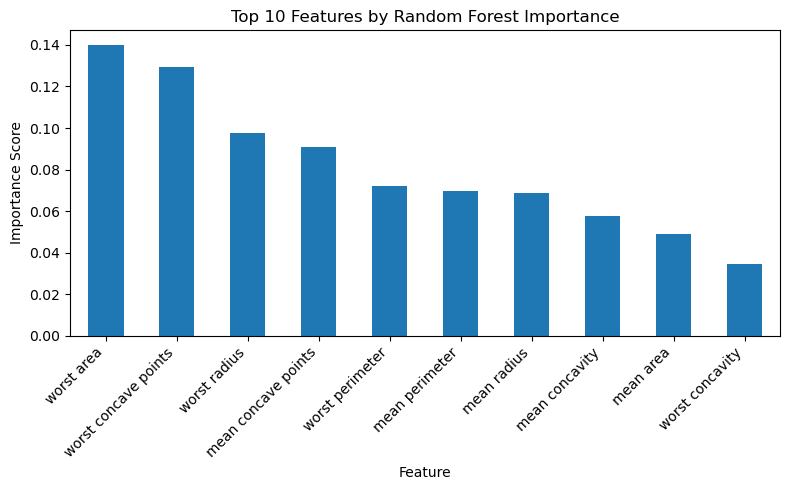

In [49]:
# Plot
plt.figure(figsize=(8, 5))
top_features.plot(kind='bar')
plt.title("Top 10 Features by Random Forest Importance")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("feature_importances.png", dpi=300, bbox_inches="tight")
plt.show()

## 5.6. Conclusion

The visualization highlights the most influential features in predicting breast cancer outcomes.  
While feature selection did not improve accuracy compared to the baseline model, it **increased interpretability** by showing which features matter most.  
In real-world projects, this understanding is often just as valuable as raw performance, especially when communicating results to non-technical stakeholders.


## 6. Discussion

It is important to note that the **baseline Logistic Regression model** already achieves very high accuracy (~98%) on this dataset.  
This happens because:
- The Breast Cancer dataset is relatively "clean" and features are highly informative.
- Logistic Regression is already well suited for this classification task.
- Feature selection removes features, which can reduce predictive information.

👉 Therefore, in this case, **feature selection does not necessarily improve accuracy**.  
Its main value lies in:
- **Interpretability**: identifying the most relevant features for the model.  
- **Efficiency**: reducing dimensionality for larger datasets.  
- **Robustness**: avoiding overfitting when working with noisier data.

**Conclusion:** Feature selection should not be expected to always outperform the baseline. Instead, it helps us understand the model better and is especially useful on high-dimensional or noisy datasets.


## 7. Conclusion
- Feature selection helps reduce dimensionality and may improve interpretability.
- Different methods may select different features, leading to slightly different results.
- For production use, combining domain knowledge with automated selection methods is recommended.
